In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv('data/Loan_Data.csv')

In [3]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [5]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


<Axes: >

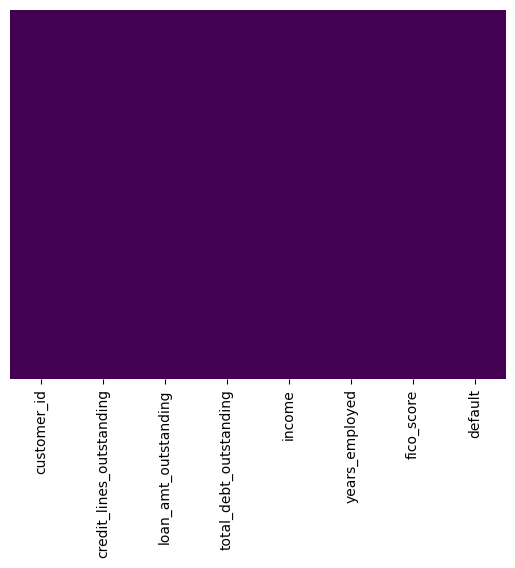

In [6]:
# Check missing values
sns.heatmap(df.isnull(), cbar=False, yticklabels=False , cmap='viridis')

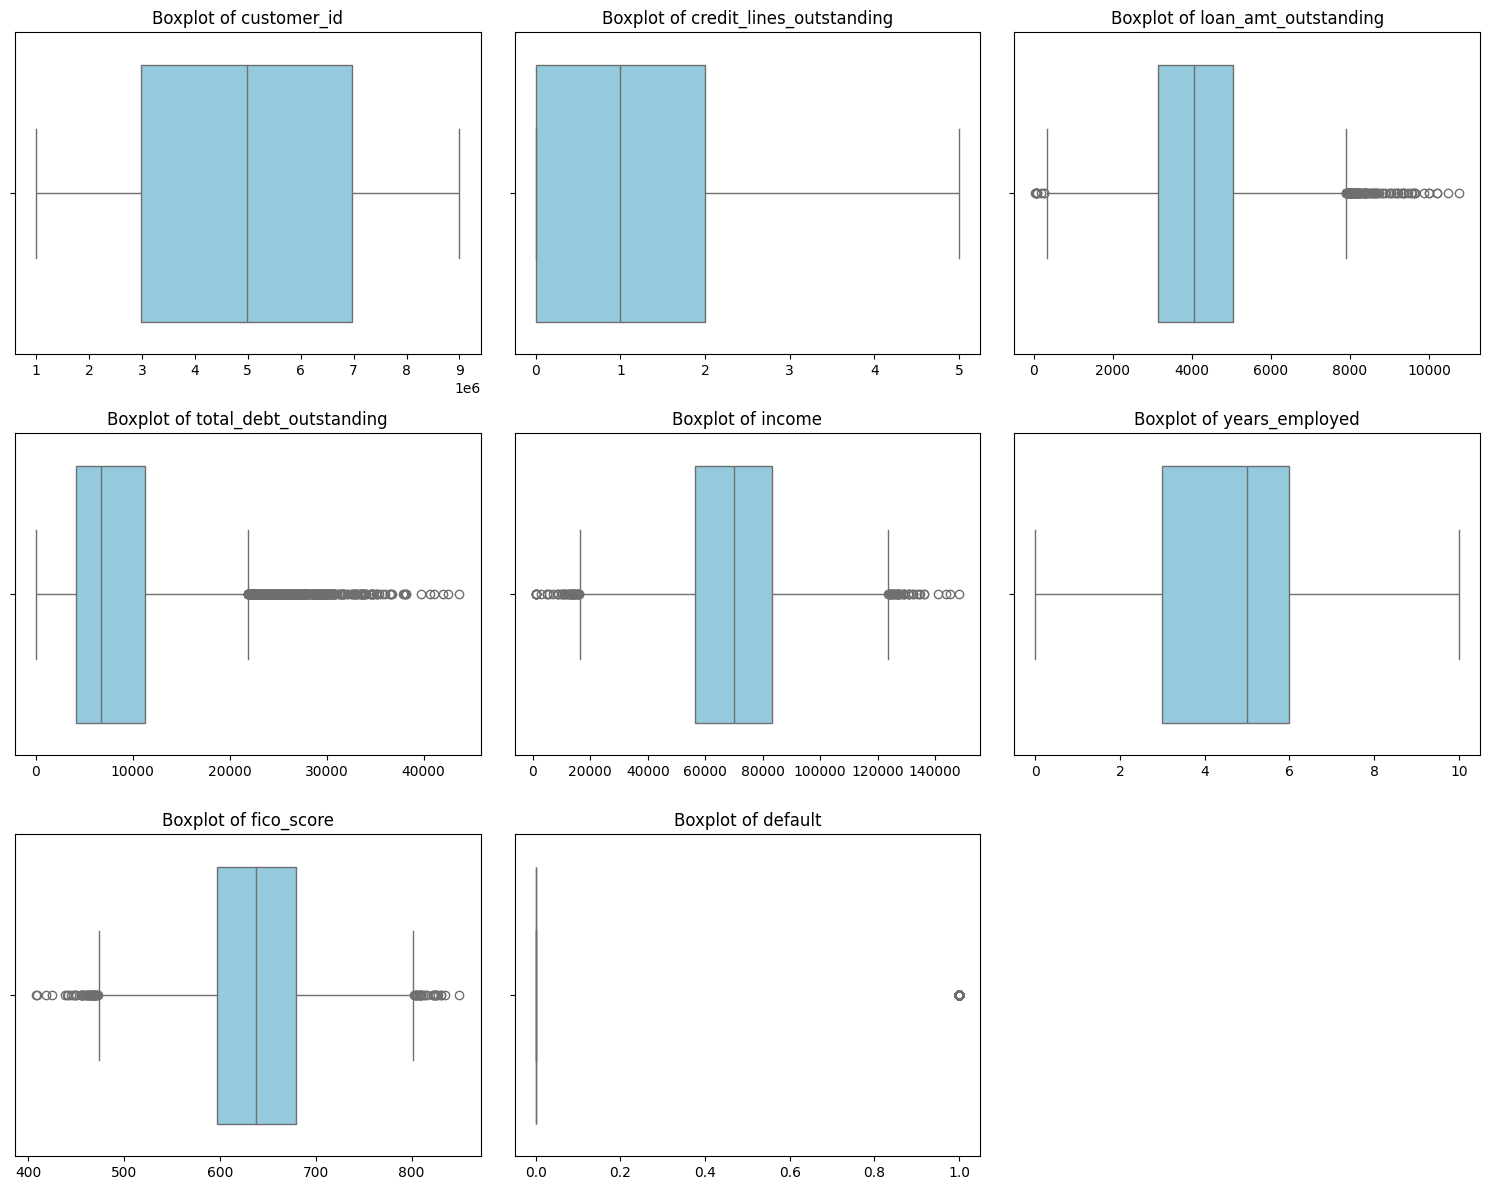

In [7]:
# 1. Sélection des colonnes numériques
numerical_features = df.select_dtypes(include=['number']).columns
n_features = len(numerical_features)

# 2. Configuration de la grille (ex: 3 colonnes)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# 3. Création de la figure unique
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # On aplatit le tableau d'axes pour boucler facilement

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel('') # Optionnel : retire le label x pour plus de clarté

# 4. Supprimer les axes vides si le nombre de features n'est pas un multiple de n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
cols_to_log = ['total_debt_outstanding', 'loan_amt_outstanding']

In [9]:
for col in cols_to_log:
    df[col] = np.log1p(df[col])

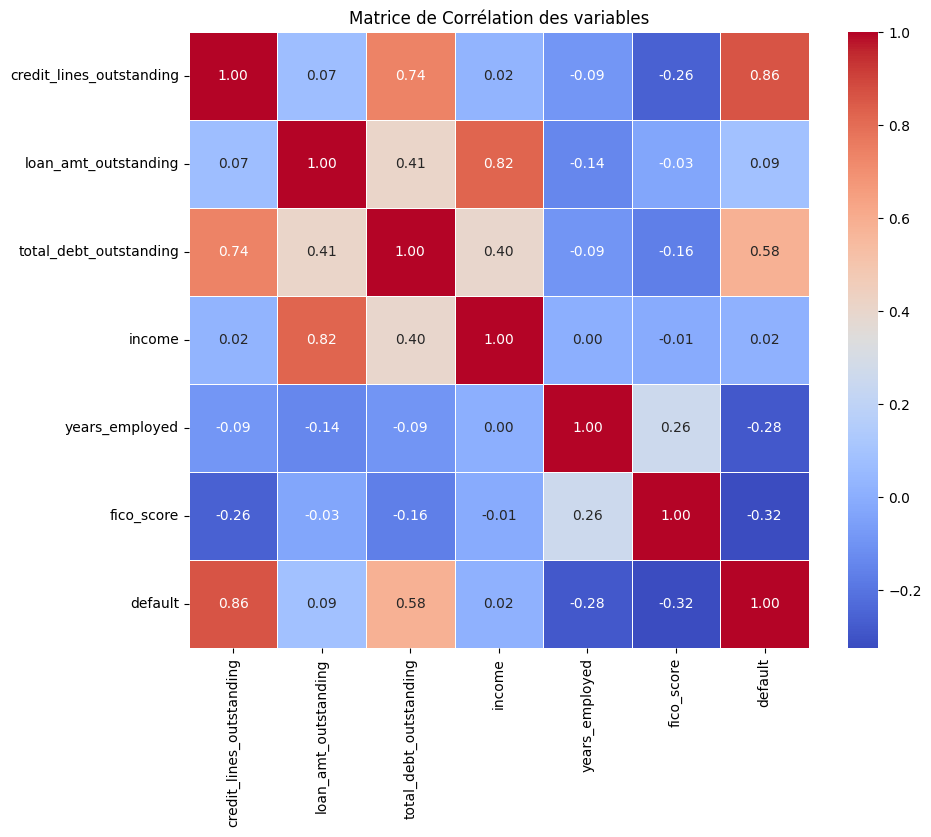

In [10]:
corr_matrix = df.drop(columns=['customer_id']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation des variables")
plt.show()

# Train Test Split

In [11]:
y = df['default']

X = df.drop(columns=['default', 'customer_id'])

# Vérification rapide
print(f"Used features : {X.columns.tolist()}")

Used features : ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']


In [12]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classification

**1 - Logistic Regression**

In [14]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.98       348

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [15]:
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
print(importance.sort_values(by='Coefficient', ascending=False))

                    Feature  Coefficient
0  credit_lines_outstanding     9.775171
2    total_debt_outstanding     2.132739
3                    income    -0.425708
1      loan_amt_outstanding    -0.428390
5                fico_score    -1.078419
4            years_employed    -2.999087


# Decision Tree

In [17]:
# 1. Définition des paramètres à tester
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None], # None = l'arbre pousse jusqu'au bout
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Configuration de la GridSearch
# On utilise cv=5 (Cross-Validation) pour être robuste
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1', # On optimise le F1-score car le défaut est une classe sensible
    n_jobs=-1
)

# 3. Entraînement
grid_search_dt.fit(X_train, y_train)

# 4. Affichage des meilleurs paramètres
print("Meilleurs paramètres Arbre :", grid_search_dt.best_params_)

# 5. Évaluation du meilleur modèle
best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print("\nReport de l'Arbre Optimisé :")
print(classification_report(y_test, y_pred_best_dt))

Meilleurs paramètres Arbre : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

Report de l'Arbre Optimisé :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [18]:
# 1. Grille de paramètres pour la forêt
param_grid_rf = {
    'n_estimators': [100, 200],           # Nombre d'arbres dans la forêt
    'max_depth': [10, 20, None],          # Profondeur de chaque arbre
    'min_samples_leaf': [1, 2, 4],        # Minimum d'échantillons par feuille
    'bootstrap': [True, False]            # Méthode de sélection des échantillons
}

# 2. Configuration GridSearch
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 3. Entraînement
grid_search_rf.fit(X_train, y_train)

# 4. Résultats
print("Meilleurs paramètres Random Forest :", grid_search_rf.best_params_)

# 5. Évaluation finale
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nReport du Random Forest Optimisé :")
print(classification_report(y_test, y_pred_rf))

Meilleurs paramètres Random Forest : {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}

Report du Random Forest Optimisé :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.99       348

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [19]:
# Récupérer l'importance des variables du Random Forest
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Récupérer les coefficients de la Régression Logistique (en valeur absolue pour comparer l'impact)
log_importances = pd.Series(abs(log_reg.coef_[0]), index=X.columns).sort_values(ascending=False)

print("TOP FEATURES - Random Forest:\n", rf_importances)
print("\nTOP FEATURES - LogReg:\n", log_importances)

TOP FEATURES - Random Forest:
 credit_lines_outstanding    0.582897
total_debt_outstanding      0.284443
years_employed              0.053018
fico_score                  0.041393
income                      0.026527
loan_amt_outstanding        0.011722
dtype: float64

TOP FEATURES - LogReg:
 credit_lines_outstanding    9.775171
years_employed              2.999087
total_debt_outstanding      2.132739
fico_score                  1.078419
loan_amt_outstanding        0.428390
income                      0.425708
dtype: float64


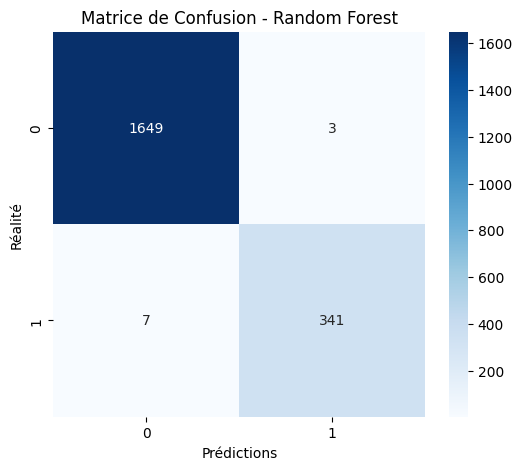

In [20]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - Random Forest')
plt.show()

In [27]:
# Save the Random Forest model
os.makedirs('models', exist_ok=True)  
joblib.dump(best_rf, 'models/credit_risk_model_rf.pkl')

# Save the scaler (in case you need it for LogReg later)
joblib.dump(scaler, 'models/scaler_credit.pkl')

print("Models saved successfully!")

Models saved successfully!
